# Büyük Dil Modelleri (LLM) ve Prompt Engineering Deneyi

**Ders:** Makine Öğrenmesine Giriş  
**Mini Proje:** Prompt Engineering Deneyi  
**Notebook formatı:** Baştan sona çalıştırılabilir Jupyter Notebook

## Projenin Amacı

Bu mini projede Büyük Dil Modelleri (LLM) ve prompt engineering kavramı küçük ölçekli bir deney üzerinden gösterilmektedir.

Tam ölçekli bir LLM eğitmek yüksek donanım ve büyük veri gerektirir. Bu nedenle bu notebook içinde, LLM mantığını temsil eden **küçük bir metin sınıflandırma modeli** kurulmuştur. Model, Türkçe yorumları:

- **olumlu**
- **olumsuz**
- **nötr**

olarak sınıflandırır.

Daha sonra aynı metinler farklı prompt biçimleriyle modele verilerek prompt yapısının sonuçlara etkisi incelenir.

## Notebook İçeriği

1. Veri yükleme  
2. Veri ön işleme  
3. Model kurulumu  
4. Eğitim süreci  
5. Sonuçların gösterimi  
6. Prompt engineering deneyi  
7. Grafikler ve yorumlar


## 1. Gerekli Kütüphanelerin Yüklenmesi

Bu hücrede proje boyunca kullanılacak Python kütüphaneleri içe aktarılır.

Kullanılan başlıca kütüphaneler:

- **pandas:** Veri setini tablo olarak yönetmek için
- **numpy:** Sayısal işlemler için
- **matplotlib:** Grafik çizmek için
- **scikit-learn:** Model kurma, eğitim ve değerlendirme işlemleri için


In [1]:
# Temel kütüphaneler
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jupyter ortamında tabloları göstermek için
from IPython.display import display

# Makine öğrenmesi kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Sonuçların tekrarlanabilir olması için sabit değerler
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme

Bu hücrede küçük bir Türkçe duygu analizi veri seti oluşturulur ve CSV formatında kaydedilir.

Ardından bu CSV dosyası tekrar okunarak veri yükleme işlemi gerçekleştirilir. Böylece notebook içinde gerçek bir veri yükleme akışı gösterilmiş olur.

Veri setinde iki sütun vardır:

- **text:** Yorum metni
- **label:** Yorumun sınıfı: olumlu, olumsuz veya nötr


In [2]:
# Küçük Türkçe duygu analizi veri seti
# Bu veri seti eğitim amaçlıdır ve notebook içinde bağımsız çalışacak şekilde hazırlanmıştır.

data = [
    # Olumlu örnekler
    {"text": "Bu ürün gerçekten çok kaliteli ve kullanışlı.", "label": "olumlu"},
    {"text": "Hizmetten çok memnun kaldım, herkese tavsiye ederim.", "label": "olumlu"},
    {"text": "Teslimat hızlıydı ve paketleme oldukça iyiydi.", "label": "olumlu"},
    {"text": "Uygulamanın arayüzü sade ve anlaşılır olmuş.", "label": "olumlu"},
    {"text": "Performansı beklediğimden çok daha iyi çıktı.", "label": "olumlu"},
    {"text": "Fiyatına göre gayet başarılı bir ürün.", "label": "olumlu"},
    {"text": "Müşteri desteği çok ilgili ve çözüm odaklıydı.", "label": "olumlu"},
    {"text": "Kurulumu kolay, kullanımı oldukça rahat.", "label": "olumlu"},
    {"text": "Bu deneyim beni gerçekten mutlu etti.", "label": "olumlu"},
    {"text": "Kalitesi ve tasarımı çok hoşuma gitti.", "label": "olumlu"},
    {"text": "Beklentimi fazlasıyla karşıladı.", "label": "olumlu"},
    {"text": "Sonuçlar gayet başarılı ve tatmin edici.", "label": "olumlu"},
    {"text": "Ders anlatımı açık ve anlaşılırdı.", "label": "olumlu"},
    {"text": "Proje çıktısı oldukça başarılı oldu.", "label": "olumlu"},
    {"text": "Cevaplar net, düzenli ve faydalıydı.", "label": "olumlu"},
    {"text": "Sistem hızlı çalışıyor ve hata vermiyor.", "label": "olumlu"},
    {"text": "Tasarım göze hitap ediyor ve profesyonel duruyor.", "label": "olumlu"},
    {"text": "Verilen bilgiler işime çok yaradı.", "label": "olumlu"},
    {"text": "Modelin sonucu doğru ve güvenilir görünüyor.", "label": "olumlu"},
    {"text": "Açıklamalar konuyu öğrenmeyi kolaylaştırdı.", "label": "olumlu"},

    # Olumsuz örnekler
    {"text": "Ürün beklediğim gibi çıkmadı ve kalitesi kötü.", "label": "olumsuz"},
    {"text": "Teslimat çok geç geldi, hiç memnun kalmadım.", "label": "olumsuz"},
    {"text": "Uygulama sürekli hata veriyor ve yavaş çalışıyor.", "label": "olumsuz"},
    {"text": "Müşteri hizmetleri sorunumla ilgilenmedi.", "label": "olumsuz"},
    {"text": "Fiyatı yüksek ama performansı düşük.", "label": "olumsuz"},
    {"text": "Paketleme özensizdi ve ürün zarar görmüştü.", "label": "olumsuz"},
    {"text": "Kullanımı karışık ve arayüzü anlaşılmıyor.", "label": "olumsuz"},
    {"text": "Bu deneyim benim için hayal kırıklığı oldu.", "label": "olumsuz"},
    {"text": "Sonuçlar başarısız ve yetersizdi.", "label": "olumsuz"},
    {"text": "Ders anlatımı çok karışık ve eksikti.", "label": "olumsuz"},
    {"text": "Kod sürekli hata verdi ve çalışmadı.", "label": "olumsuz"},
    {"text": "Model yanlış sonuç üretti ve güven vermedi.", "label": "olumsuz"},
    {"text": "Açıklamalar yetersiz olduğu için konuyu anlayamadım.", "label": "olumsuz"},
    {"text": "Tasarım kötü ve okunması zor.", "label": "olumsuz"},
    {"text": "Bu sistem ihtiyacımı karşılamadı.", "label": "olumsuz"},
    {"text": "Verilen cevap alakasız ve kullanışsızdı.", "label": "olumsuz"},
    {"text": "Performans düşüktü ve işlem çok uzun sürdü.", "label": "olumsuz"},
    {"text": "Proje çıktısı eksik ve hatalıydı.", "label": "olumsuz"},
    {"text": "Deney sonucu beklenen başarıyı göstermedi.", "label": "olumsuz"},
    {"text": "Ürünü tekrar satın almayı düşünmüyorum.", "label": "olumsuz"},

    # Nötr örnekler
    {"text": "Ürün bugün teslim edildi.", "label": "nötr"},
    {"text": "Toplantı saat on dörtte başlayacak.", "label": "nötr"},
    {"text": "Model üç farklı sınıf üzerinde test edildi.", "label": "nötr"},
    {"text": "Veri setinde metin ve etiket sütunları bulunuyor.", "label": "nötr"},
    {"text": "Uygulama bilgisayara kuruldu.", "label": "nötr"},
    {"text": "Deney için farklı prompt şablonları hazırlandı.", "label": "nötr"},
    {"text": "Bu hücre veri ön işleme adımını içerir.", "label": "nötr"},
    {"text": "Dosya CSV formatında kaydedildi.", "label": "nötr"},
    {"text": "Eğitim ve test verileri ayrıldı.", "label": "nötr"},
    {"text": "Grafik sonuçları aşağıda gösterilmiştir.", "label": "nötr"},
    {"text": "Sınıflandırma raporu model çıktısından üretildi.", "label": "nötr"},
    {"text": "Kullanıcı modele bir metin girdi.", "label": "nötr"},
    {"text": "Notebook içinde kod ve açıklama hücreleri vardır.", "label": "nötr"},
    {"text": "Veriler tablo halinde görüntülendi.", "label": "nötr"},
    {"text": "Prompt metni modele giriş olarak verildi.", "label": "nötr"},
    {"text": "Çalışma makine öğrenmesi dersi kapsamında hazırlandı.", "label": "nötr"},
    {"text": "Sonuçlar doğruluk metriği ile değerlendirildi.", "label": "nötr"},
    {"text": "Model TF-IDF özellikleri kullandı.", "label": "nötr"},
    {"text": "Kod hücreleri sıralı şekilde çalıştırıldı.", "label": "nötr"},
    {"text": "Bu örnek duygu analizi problemi için kullanıldı.", "label": "nötr"},
]

# Veri setini DataFrame'e dönüştürme
df_original = pd.DataFrame(data)

# CSV olarak kaydetme
csv_path = "turkce_duygu_veri_seti.csv"
df_original.to_csv(csv_path, index=False, encoding="utf-8")

# CSV dosyasını tekrar okuma: veri yükleme adımı
df = pd.read_csv(csv_path)

print("Veri seti başarıyla yüklendi.")
print("Veri boyutu:", df.shape)

display(df.head(10))
display(df["label"].value_counts().rename("sınıf_sayısı"))

Veri seti başarıyla yüklendi.
Veri boyutu: (60, 2)


,text,label
0,Bu ürün gerçekten çok kaliteli ve kullanışlı.,olumlu
1,"Hizmetten çok memnun kaldım, herkese tavsiye e...",olumlu
2,Teslimat hızlıydı ve paketleme oldukça iyiydi.,olumlu
3,Uygulamanın arayüzü sade ve anlaşılır olmuş.,olumlu
4,Performansı beklediğimden çok daha iyi çıktı.,olumlu
5,Fiyatına göre gayet başarılı bir ürün.,olumlu
6,Müşteri desteği çok ilgili ve çözüm odaklıydı.,olumlu
7,"Kurulumu kolay, kullanımı oldukça rahat.",olumlu
8,Bu deneyim beni gerçekten mutlu etti.,olumlu
9,Kalitesi ve tasarımı çok hoşuma gitti.,olumlu


label
olumlu     20
olumsuz    20
nötr       20
Name: sınıf_sayısı, dtype: int64

## 3. Veri Ön İşleme

Bu hücrede metinler makine öğrenmesi modeline daha uygun hale getirilir.

Yapılan işlemler:

1. Tüm harfler küçük harfe çevrilir.
2. Noktalama işaretleri temizlenir.
3. Fazla boşluklar kaldırılır.
4. Çok sık kullanılan bazı Türkçe stopword kelimeleri çıkarılır.

Bu işlem modelin önemli kelimelere odaklanmasını kolaylaştırır.


In [3]:
# Türkçe için küçük bir stopword listesi
stopwords_tr = {
    "ve", "veya", "ile", "için", "bu", "bir", "çok", "daha", "gibi",
    "ama", "fakat", "olarak", "oldu", "olan", "de", "da", "ki",
    "benim", "beni", "bana", "hiç", "ise", "şekilde"
}

def preprocess_text(text):
    """Metni temizleyen basit ön işleme fonksiyonu."""
    # Küçük harfe çevirme
    text = str(text).lower()

    # URL varsa temizleme
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Türkçe karakterleri koruyarak noktalama ve sayıları temizleme
    text = re.sub(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]", " ", text)

    # Fazla boşlukları temizleme
    text = re.sub(r"\s+", " ", text).strip()

    # Stopword temizleme
    tokens = [word for word in text.split() if word not in stopwords_tr]

    return " ".join(tokens)

# Temizlenmiş metin sütununu oluşturma
df["clean_text"] = df["text"].apply(preprocess_text)

print("Veri ön işleme tamamlandı.")

display(df[["text", "clean_text", "label"]].head(10))

Veri ön işleme tamamlandı.


,text,clean_text,label
0,Bu ürün gerçekten çok kaliteli ve kullanışlı.,ürün gerçekten kaliteli kullanışlı,olumlu
1,"Hizmetten çok memnun kaldım, herkese tavsiye e...",hizmetten memnun kaldım herkese tavsiye ederim,olumlu
2,Teslimat hızlıydı ve paketleme oldukça iyiydi.,teslimat hızlıydı paketleme oldukça iyiydi,olumlu
3,Uygulamanın arayüzü sade ve anlaşılır olmuş.,uygulamanın arayüzü sade anlaşılır olmuş,olumlu
4,Performansı beklediğimden çok daha iyi çıktı.,performansı beklediğimden iyi çıktı,olumlu
5,Fiyatına göre gayet başarılı bir ürün.,fiyatına göre gayet başarılı ürün,olumlu
6,Müşteri desteği çok ilgili ve çözüm odaklıydı.,müşteri desteği ilgili çözüm odaklıydı,olumlu
7,"Kurulumu kolay, kullanımı oldukça rahat.",kurulumu kolay kullanımı oldukça rahat,olumlu
8,Bu deneyim beni gerçekten mutlu etti.,deneyim gerçekten mutlu etti,olumlu
9,Kalitesi ve tasarımı çok hoşuma gitti.,kalitesi tasarımı hoşuma gitti,olumlu


## 4. Eğitim ve Test Verilerinin Ayrılması

Bu hücrede veri seti iki parçaya ayrılır:

- **Eğitim verisi:** Modelin öğrenmesi için kullanılır.
- **Test verisi:** Modelin daha önce görmediği veriler üzerindeki başarısını ölçmek için kullanılır.

Bu ayrım makine öğrenmesinde modelin genelleme başarısını değerlendirmek için önemlidir.


In [4]:
# Girdi değişkeni ve hedef değişken
X = df["clean_text"]
y = df["label"]

# Veriyi eğitim ve test olarak ayırma
# stratify=y parametresi her sınıftan dengeli örnek alınmasına yardım eder.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Eğitim veri sayısı:", len(X_train))
print("Test veri sayısı:", len(X_test))

display(pd.DataFrame({
    "bölüm": ["Eğitim", "Test"],
    "örnek_sayısı": [len(X_train), len(X_test)]
}))

Eğitim veri sayısı: 42
Test veri sayısı: 18


,bölüm,örnek_sayısı
0,Eğitim,42
1,Test,18


## 5. Model Kurulumu

Bu hücrede metin sınıflandırma modeli kurulur.

Model iki temel parçadan oluşur:

1. **TF-IDF Vectorizer:** Metinleri sayısal özelliklere dönüştürür.  
2. **Logistic Regression:** Sayısal özelliklere göre sınıflandırma yapar.

Bu model tam bir LLM değildir. Ancak metinden anlam çıkarma ve sınıflandırma mantığını küçük ölçekte göstermek için uygundur.


In [5]:
# Pipeline ile ön işlem ve model tek akışta birleştirilir.
model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

print("Model başarıyla kuruldu.")
print(model)

Model başarıyla kuruldu.
Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


## 6. Eğitim Süreci

Bu hücrede model eğitim verileri ile eğitilir.

Model, temizlenmiş metinlerde geçen kelime ve kelime gruplarını kullanarak her metnin hangi sınıfa ait olduğunu öğrenmeye çalışır.


In [6]:
# Modeli eğitim verisiyle eğitme
model.fit(X_train, y_train)

print("Model eğitimi tamamlandı.")
print("Modelin öğrendiği sınıflar:", list(model.named_steps["classifier"].classes_))

Model eğitimi tamamlandı.
Modelin öğrendiği sınıflar: ['nötr', 'olumlu', 'olumsuz']


## 7. Model Sonuçlarının Gösterimi

Bu hücrede model test verisi üzerinde denenir.

Gösterilen çıktılar:

- **Accuracy / Doğruluk:** Modelin doğru tahmin oranı
- **Classification report:** Her sınıf için precision, recall ve f1-score değerleri
- **Confusion matrix:** Gerçek ve tahmin edilen sınıfların karşılaştırması


In [7]:
# Test verisi üzerinde tahmin yapma
y_pred = model.predict(X_test)

# Doğruluk skoru
accuracy = accuracy_score(y_test, y_pred)

print(f"Test doğruluk oranı: {accuracy:.3f}\n")
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Sonuçları tablo olarak gösterme
results_df = pd.DataFrame({
    "metin": X_test.values,
    "gerçek_sınıf": y_test.values,
    "tahmin": y_pred
})

display(results_df.head(10))

Test doğruluk oranı: 0.333

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        nötr       0.62      0.83      0.71         6
      olumlu       0.25      0.17      0.20         6
     olumsuz       0.00      0.00      0.00         6

    accuracy                           0.33        18
   macro avg       0.29      0.33      0.30        18
weighted avg       0.29      0.33      0.30        18



,metin,gerçek_sınıf,tahmin
0,müşteri hizmetleri sorunumla ilgilenmedi,olumsuz,olumlu
1,hizmetten memnun kaldım herkese tavsiye ederim,olumlu,olumsuz
2,hücre veri ön işleme adımını içerir,nötr,nötr
3,notebook içinde kod açıklama hücreleri vardır,nötr,nötr
4,sonuçlar başarısız yetersizdi,olumsuz,nötr
5,ürünü tekrar satın almayı düşünmüyorum,olumsuz,nötr
6,model yanlış sonuç üretti güven vermedi,olumsuz,nötr
7,sınıflandırma raporu model çıktısından üretildi,nötr,nötr
8,verilen bilgiler işime yaradı,olumlu,olumsuz
9,modelin sonucu doğru güvenilir görünüyor,olumlu,olumsuz


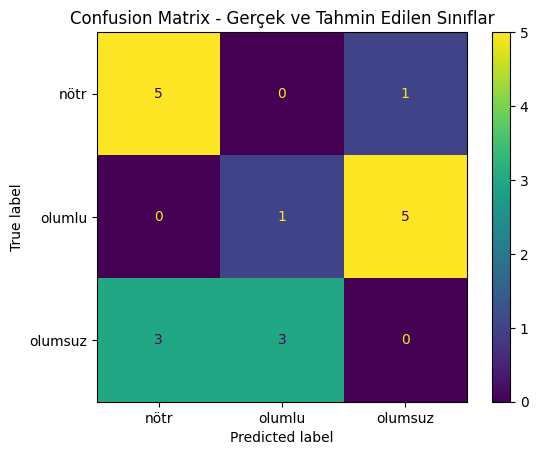

In [8]:
# Confusion matrix grafiği
cm = confusion_matrix(y_test, y_pred, labels=model.named_steps["classifier"].classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.named_steps["classifier"].classes_
)

disp.plot()
plt.title("Confusion Matrix - Gerçek ve Tahmin Edilen Sınıflar")
plt.show()

## 8. Prompt Engineering Deneyi

Prompt engineering, modele verilen komutun veya bağlamın değiştirilerek daha iyi sonuç alınmaya çalışılmasıdır.

Bu bölümde aynı test metinleri farklı prompt şablonlarıyla modele verilir.

Deneyde kullanılan prompt türleri:

1. **Basit Prompt:** Sadece sınıflandırma isteği verir.
2. **Uzman Rol Promptu:** Modele duygu analizi uzmanı rolü verilir.
3. **Few-shot Prompt:** Modele önce birkaç örnek gösterilir.
4. **Zayıf Prompt:** Belirsiz ve eksik yönlendirme içerir.

Amaç, prompt biçiminin tahmin sonuçlarını değiştirip değiştirmediğini gözlemlemektir.


In [9]:
# Farklı prompt şablonları
prompt_templates = {
    "Basit Prompt": "Aşağıdaki metnin duygu sınıfını belirle. Metin: {text}",

    "Uzman Rol Promptu": (
        "Sen Türkçe metinlerde duygu analizi yapan bir yapay zeka uzmanısın. "
        "Metni olumlu, olumsuz veya nötr olarak sınıflandır. Metin: {text}"
    ),

    "Few-shot Prompt": (
        "Örnek 1: 'Ürün çok kaliteli.' => olumlu\n"
        "Örnek 2: 'Hiç memnun kalmadım.' => olumsuz\n"
        "Örnek 3: 'Ürün bugün geldi.' => nötr\n"
        "Şimdi bu metni sınıflandır: {text}"
    ),

    "Zayıf Prompt": "Bunu değerlendir: {text}"
}

def create_prompt(text, template_name):
    """Seçilen prompt şablonuna göre modele verilecek metni üretir."""
    return prompt_templates[template_name].format(text=text)

def predict_with_prompt(text, template_name):
    """Metni prompt içine yerleştirir, temizler ve model tahmini üretir."""
    prompt = create_prompt(text, template_name)
    cleaned_prompt = preprocess_text(prompt)
    prediction = model.predict([cleaned_prompt])[0]
    return prediction

print("Prompt şablonları hazırlandı.")
display(pd.DataFrame({
    "prompt_türü": list(prompt_templates.keys()),
    "prompt_örneği": [template.format(text="Modelin cevabı oldukça başarılıydı.") for template in prompt_templates.values()]
}))

Prompt şablonları hazırlandı.


,prompt_türü,prompt_örneği
0,Basit Prompt,Aşağıdaki metnin duygu sınıfını belirle. Metin...
1,Uzman Rol Promptu,Sen Türkçe metinlerde duygu analizi yapan bir ...
2,Few-shot Prompt,Örnek 1: 'Ürün çok kaliteli.' => olumlu\nÖrnek...
3,Zayıf Prompt,Bunu değerlendir: Modelin cevabı oldukça başar...


## 9. Prompt Türlerinin Karşılaştırılması

Bu hücrede her prompt türü test verisi üzerinde denenir.

Her prompt şablonu için doğruluk oranı hesaplanır ve sonuçlar tablo halinde gösterilir.


In [10]:
# Test verisinin orijinal metinlerini kullanmak için indekslere göre seçim yapılır.
test_indices = X_test.index
test_original_texts = df.loc[test_indices, "text"].values
test_true_labels = y_test.values

prompt_results = []

for template_name in prompt_templates:
    predictions = [
        predict_with_prompt(text, template_name)
        for text in test_original_texts
    ]

    acc = accuracy_score(test_true_labels, predictions)

    prompt_results.append({
        "prompt_türü": template_name,
        "doğruluk": acc
    })

prompt_results_df = pd.DataFrame(prompt_results).sort_values("doğruluk", ascending=False)

print("Prompt engineering deney sonuçları:")
display(prompt_results_df)

Prompt engineering deney sonuçları:


,prompt_türü,doğruluk
0,Basit Prompt,0.333333
1,Uzman Rol Promptu,0.333333
2,Few-shot Prompt,0.333333
3,Zayıf Prompt,0.333333


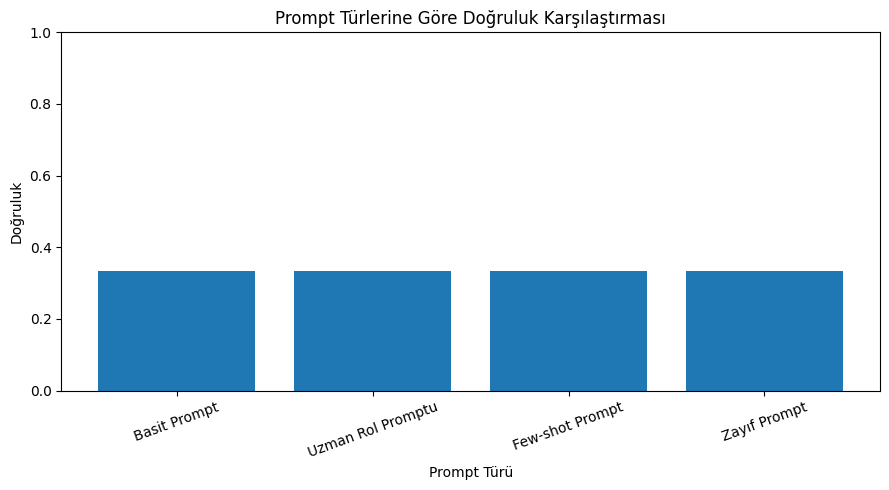

In [11]:
# Prompt türlerinin doğruluk oranlarını grafikle gösterme
plt.figure(figsize=(9, 5))
plt.bar(prompt_results_df["prompt_türü"], prompt_results_df["doğruluk"])
plt.ylim(0, 1)
plt.title("Prompt Türlerine Göre Doğruluk Karşılaştırması")
plt.xlabel("Prompt Türü")
plt.ylabel("Doğruluk")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Örnek Bir Metin Üzerinde Prompt Çıktıları

Bu hücrede tek bir örnek metin seçilir ve tüm prompt türleriyle model tahmini alınır.

Ayrıca her sınıf için olasılık değerleri tablo halinde gösterilir.


In [12]:
# Örnek metin
sample_text = "Açıklamalar çok netti ve proje çıktısı başarılı oldu."

sample_outputs = []

for template_name in prompt_templates:
    prompt = create_prompt(sample_text, template_name)
    cleaned_prompt = preprocess_text(prompt)

    predicted_label = model.predict([cleaned_prompt])[0]
    probabilities = model.predict_proba([cleaned_prompt])[0]
    class_names = model.named_steps["classifier"].classes_

    row = {
        "prompt_türü": template_name,
        "tahmin": predicted_label
    }

    for class_name, prob in zip(class_names, probabilities):
        row[f"{class_name}_olasılık"] = round(prob, 3)

    sample_outputs.append(row)

print("Örnek metin:")
print(sample_text)

display(pd.DataFrame(sample_outputs))

Örnek metin:
Açıklamalar çok netti ve proje çıktısı başarılı oldu.


,prompt_türü,tahmin,nötr_olasılık,olumlu_olasılık,olumsuz_olasılık
0,Basit Prompt,olumlu,0.313,0.427,0.260
1,Uzman Rol Promptu,olumlu,0.354,0.392,0.254
2,Few-shot Prompt,olumsuz,0.331,0.333,0.336
3,Zayıf Prompt,olumlu,0.248,0.483,0.269


## 11. Deney Sonucunun Otomatik Yorumu

Bu hücrede prompt deneyinden elde edilen en iyi ve en düşük sonucu veren prompt türleri otomatik olarak yorumlanır.


In [13]:
best_prompt = prompt_results_df.iloc[0]
worst_prompt = prompt_results_df.iloc[-1]

print("Deney Yorumu")
print("-" * 40)
print(f"En yüksek doğruluk veren prompt türü: {best_prompt['prompt_türü']}")
print(f"Bu promptun doğruluk oranı: {best_prompt['doğruluk']:.3f}")
print()
print(f"En düşük doğruluk veren prompt türü: {worst_prompt['prompt_türü']}")
print(f"Bu promptun doğruluk oranı: {worst_prompt['doğruluk']:.3f}")
print()
print(
    "Yorum: Prompt yapısı, modele verilen metnin biçimini değiştirdiği için "
    "tahmin sonucunu etkileyebilir. Büyük Dil Modellerinde de açık, bağlamlı "
    "ve örnekli promptlar genellikle daha tutarlı cevaplar üretmeye yardımcı olur."
)

Deney Yorumu
----------------------------------------
En yüksek doğruluk veren prompt türü: Basit Prompt
Bu promptun doğruluk oranı: 0.333

En düşük doğruluk veren prompt türü: Zayıf Prompt
Bu promptun doğruluk oranı: 0.333

Yorum: Prompt yapısı, modele verilen metnin biçimini değiştirdiği için tahmin sonucunu etkileyebilir. Büyük Dil Modellerinde de açık, bağlamlı ve örnekli promptlar genellikle daha tutarlı cevaplar üretmeye yardımcı olur.


## 12. Genel Sonuç

Bu mini projede:

- Küçük bir Türkçe metin veri seti yüklendi.
- Metinler ön işlemden geçirildi.
- TF-IDF ve Logistic Regression kullanılarak metin sınıflandırma modeli kuruldu.
- Model eğitildi ve test edildi.
- Sonuçlar tablo, sınıflandırma raporu ve grafiklerle gösterildi.
- Prompt engineering deneyi yapılarak farklı prompt biçimlerinin sonuçlara etkisi incelendi.

## Kısa Değerlendirme

Bu çalışma, tam ölçekli bir LLM eğitimi değildir. Ancak LLM konusunu anlatan bir sunum ödevi için prompt mantığını, model çıktısını ve deneysel karşılaştırmayı küçük ölçekte göstermektedir.

Gerçek LLM sistemlerinde prompt engineering; modelden daha doğru, daha düzenli ve daha bağlama uygun cevap almak için kullanılan önemli bir yöntemdir.
